In [10]:
import os
import joblib
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from string import punctuation
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [11]:
df = pd.read_csv("Symptom2Disease.csv")
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [12]:
#preprocess function
def tag_to_wordnet(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess(sentence):
    # tokenizations
    tokens = word_tokenize(sentence)
    # cleaning
    cleaned_tokens = [ token.lower() for token in tokens if token.lower() not in stopwords.words('english') and token.lower() not in punctuation]
    # pos tag
    tagged_tokens = pos_tag(cleaned_tokens)
    # lemma
    lemmatized_tokens = [

        WordNetLemmatizer().lemmatize(
            token,
            tag_to_wordnet(tag)
        )
        for token, tag in tagged_tokens
    ]

    return lemmatized_tokens

df['clean_text'] = df['text'].apply(preprocess)

print(df[['text', 'clean_text']].head())

                                                text  \
0  I have been experiencing a skin rash on my arm...   
1  My skin has been peeling, especially on my kne...   
2  I have been experiencing joint pain in my fing...   
3  There is a silver like dusting on my skin, esp...   
4  My nails have small dents or pits in them, and...   

                                          clean_text  
0  [experience, skin, rash, arm, legs, torso, pas...  
1  [skin, peel, especially, knee, elbow, scalp, p...  
2  [experience, joint, pain, finger, wrists, knee...  
3  [silver, like, dust, skin, especially, low, ba...  
4  [nail, small, dent, pit, often, feel, inflamma...  


In [13]:
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [14]:
print("Training Word2Vec model...")

w2v_model = Word2Vec(sentences = X_train, vector_size = 100, window = 5, min_count = 1, workers = 4, sg=1)
print("Word2Vec model trained!")

Training Word2Vec model...
Word2Vec model trained!


In [15]:
def sentence_vector(tokens):

    vectors = []

    for word in tokens:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)


X_train_w2v = np.array([sentence_vector(tokens) for tokens in X_train])
X_test_w2v = np.array([sentence_vector(tokens) for tokens in X_test])

In [16]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
 )
model.fit(X_train_w2v, y_train)

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/word2vec_model.joblib", compress=True)
w2v_model.save("models/word2vec_vectors.model")

In [17]:
from sklearn.metrics import precision_recall_fscore_support

y_pred = model.predict(X_test_w2v)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
 )

metrics_df = pd.DataFrame([
    {
        "metric": "accuracy",
        "value": accuracy
    },
    {
        "metric": "weighted_precision",
        "value": weighted_precision
    },
    {
        "metric": "weighted_recall",
        "value": weighted_recall
    },
    {
        "metric": "weighted_f1",
        "value": weighted_f1
    }
])

print(metrics_df)

Accuracy : 0.8833333333333333

Classification Report

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.79      1.00      0.88        11
           Cervical spondylosis       0.88      1.00      0.93         7
                    Chicken pox       0.50      0.50      0.50        12
                    Common Cold       1.00      0.83      0.91        12
                         Dengue       0.67      0.67      0.67        12
          Dimorphic Hemorrhoids       0.88      1.00      0.93         7
               Fungal infection       1.00      1.00      1.00        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      0.91      0.95        11
                       Jaundice       1.00      1.00      1.00       

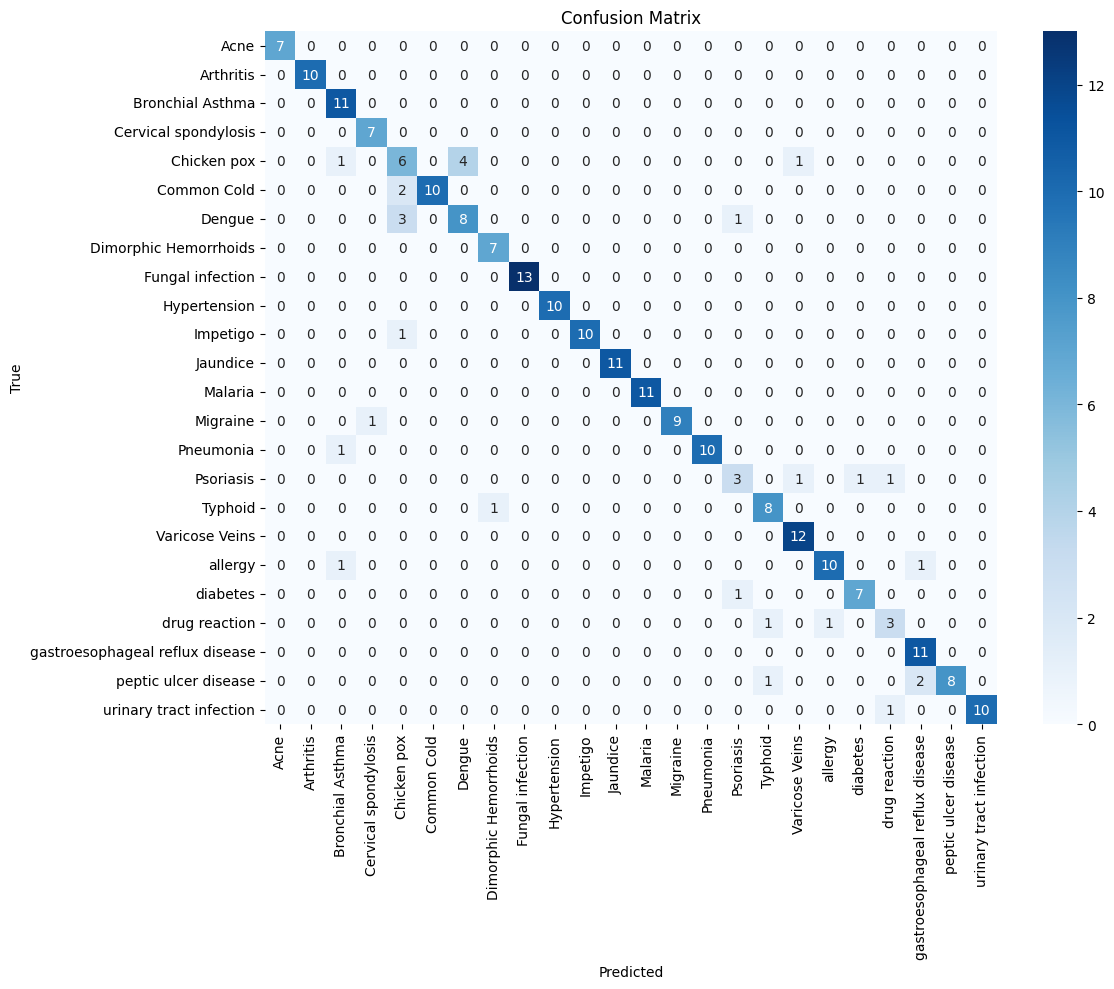

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
 )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()